# LSTM Forex Trading Strategy
### Recreating: Predictive modeling of foreign exchange trading signals using machine learning techniques

**Authors:** Sugarbayar Enkhbayar, Robert Ślepaczuk  
**Journal:** Expert Systems With Applications (2025)

---

## Step 1: Data Loading & Exploration

We'll start by loading the forex data and understanding its structure.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load forex data
# According to the study, they used 6 major pairs: EURUSD, GBPUSD, USDCHF, USDCAD, AUDUSD, NZDUSD
# We have: EURUSD, GBPUSD, AUDUSD, USDJPY

# Let's start with EURUSD daily data
df = pd.read_csv('data/EURUSD_1day.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Set date as index
df.set_index('date', inplace=True)

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nDate range: {df.index.min()} to {df.index.max()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (6743, 5)

Date range: 2000-01-03 00:00:00 to 2025-11-07 00:00:00

First few rows:


,open,high,low,close,volume
date,,,,,
2000-01-03,1.00741,1.02861,1.00531,1.02451,0
2000-01-04,1.02451,1.03421,1.02181,1.03011,0
2000-01-05,1.03011,1.04041,1.02861,1.03261,0
2000-01-06,1.03261,1.04151,1.02811,1.03301,0
2000-01-07,1.03301,1.03351,1.02561,1.02881,0


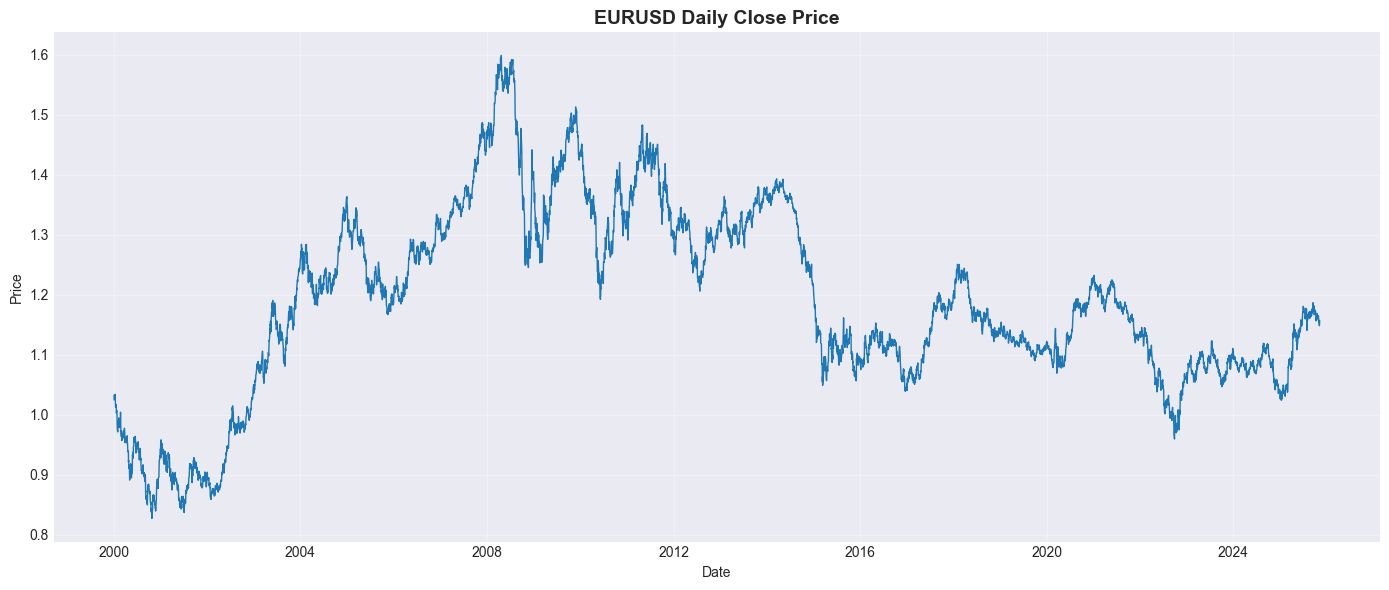

In [4]:
# Visualize the close price over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['close'], linewidth=1)
plt.title('EURUSD Daily Close Price', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Calculate simple returns
df['simple_return'] = df['close'].pct_change()

# Calculate log returns
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

# Display return statistics
print("Return Statistics:")
print(f"\nSimple Return - Mean: {df['simple_return'].mean():.6f}")
print(f"Simple Return - Std: {df['simple_return'].std():.6f}")
print(f"\nLog Return - Mean: {df['log_return'].mean():.6f}")
print(f"Log Return - Std: {df['log_return'].std():.6f}")

Return Statistics:

Simple Return - Mean: 0.000035
Simple Return - Std: 0.005798

Log Return - Mean: 0.000018
Log Return - Std: 0.005797


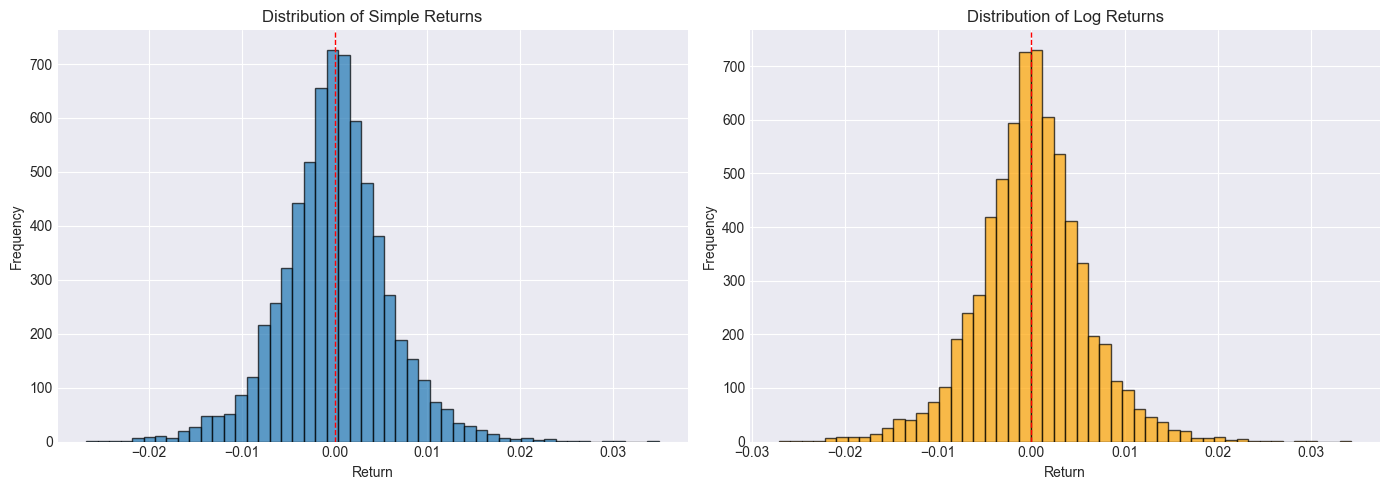

In [6]:
# Visualize return distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simple returns
axes[0].hist(df['simple_return'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Simple Returns')
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)

# Log returns
axes[1].hist(df['log_return'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Distribution of Log Returns')
axes[1].set_xlabel('Return')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()